# Lesson 1: The Lay of the Land

This lesson is a flyover of the machine learning landscape. The goal isn't to understand how anything works yet, it's to see what's possible, learn the vocabulary, and build a mental map of the field that every future lesson will fill in. This course will have a top-down approach - it means we'll start off working very practical, and then we'll start going into depth of the concepts in future lessons more (starting lesson 3). Lesson 1-2 are heavily focused on just trying things out and seeing the magic of machine learning.

### A quick word on learning machine learning

If you've got a coding background learning machine learning will still be hard, but it really helps that you know coding. But learning ML can really feel like you are introduced with a wall of new concepts and terminology, and it's going to take a while to get used to all the new stuff. You'll mix things up, and that's completely fine. Learning ML is a long process, probably a year at least to get somewhat comfortable and not constantly second guessing things.

Now, that's one thing. Another painful part is that it's always difficult to know how deep you should try to understand something. My advice here is that you don't have to dive too deep into details, instead, remember that your goal is to be productive but still have a good feel for the process. And so, you might feel like you really want to understand the chain rule and backpropagation, but sometimes these really difficult concept requires us to let go. Yepp, LET GO! Don't obsess over understanding how everything exactly works - maybe it's sometimes enough to just understand "if I use this weird thing called batch normalization, that will help my machine learning model and reduce overfitting". Now, you could deepdive into what "batch normalization" is, but you could also just accept that it's a cool thing some smart person invented in a scienctific white paper and everyone just seems to use it.

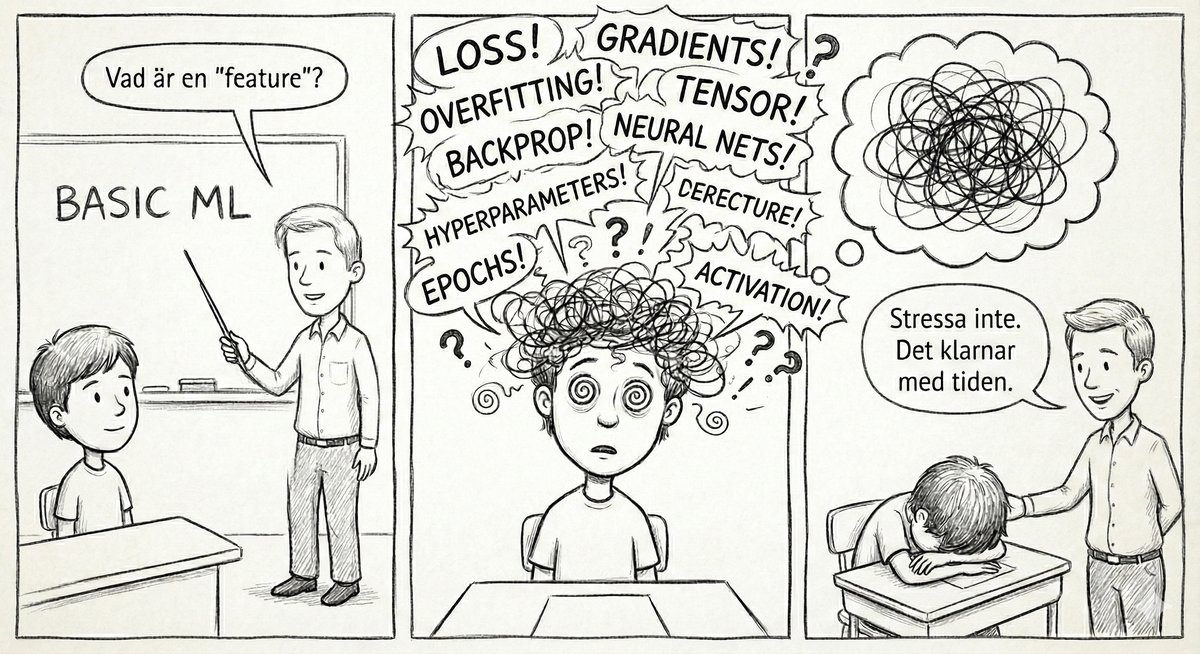

In swedish, we say "släpp sargen", or "kom in i matchen", what we mean is: let go, accept that some stuff is magical and it just works. And realize that your goal is ultimately to be productive with using ML - deeper knowledge will come in time. But you should absolutely try to understand a lot of the concepts, you might just not need to understand the math or details behind them at all times.

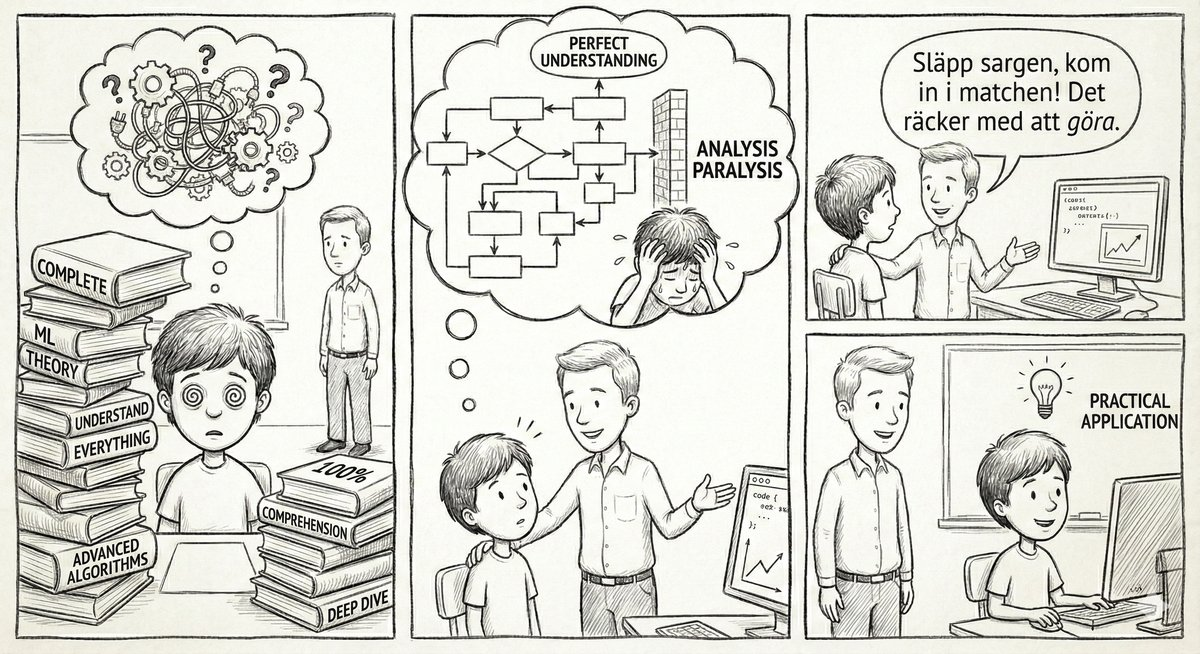

### Setting up your environment

We recommend using conda (or miniforge) to manage your Python environment. Create a dedicated environment for this course:

```bash
conda create -n ml-venv python=3.11 -y
conda activate ml-venv
```

Then install all the packages we'll use throughout the course:

```bash
pip install torch torchvision --index-url https://download.pytorch.org/whl/cu128
pip install fastai scikit-learn pandas numpy matplotlib
pip install transformers xgboost lightgbm
pip install opencv-python ipykernel
```

If you don't have a NVIDIA GPU, replace `cu128` with `cpu` in the torch install line. After installing, register the kernel for Jupyter:

```bash
python -m ipykernel install --user --name ml-venv --display-name "ml-venv"
```

Then select "ml-venv" as the kernel when opening notebooks in VS Code or JupyterLab.

## What is Machine Learning?

### Data Helps Us Make Predictions

Think about how a doctor diagnoses a patient. They don't start from scratch every time - they've seen thousands of patients before. They've noticed patterns: these symptoms usually mean this condition, this blood test result combined with this age group usually points to that. Their past experience (historical data) helps them predict what's happening with the current patient.

Machine learning does the same thing, but with a computer. You give it historical data where you already know the outcome, and it finds patterns it can use to predict outcomes for new data where you don't know the answer yet.

This is the core idea: **historical data with known outcomes helps us predict future outcomes**.

Here are some real examples of this in practice:

| Historical data you have | What you want to predict |
|-------------------------------|---------------------------|
| 20,640 California districts with median house values from the 1990 census | What a house in a new district would be worth |
| 284,807 credit card transactions, 492 of which were fraudulent | Whether this transaction happening right now is fraud |
| 7,393 photos of 37 cat and dog breeds, each labeled with the breed name | What breed is the animal in this new photo |
| 891 Titanic passengers with survival records | Whether a passenger with certain characteristics would have survived |

The "known outcomes" in the historical data are called **labels** - they're the answers. The information about each example (house size, transaction amount, pixel values) are called **features** - they're the inputs. A **model** is the thing that learns the relationship between features and labels.

All four of those datasets are real, and we'll actually work with most of them in this course.

### Traditional Programming vs Machine Learning

In traditional programming, you write rules: "if the email contains these words, it's spam." Machine learning flips that - instead of writing rules, you show the system thousands of examples of spam and not-spam, and it figures out the rules on its own. The rules it discovers are often subtler and more effective than anything a human would write by hand.

| Traditional Programming | Machine Learning |
|------------------------|-----------------|
| You write the rules | The algorithm discovers the rules |
| Rules + Data = Answers | Data + Answers = Rules |
| Breaks when patterns change | Retrain on new examples |
| Hard to scale to complex problems | Scales with data |

Here's what that looks like in practice. Say you want to predict whether an email is spam. Each email becomes a row of data:

| Email text | Contains link? | ALL CAPS words | Known sender? | **Spam?** |
|-----------|:-:|:-:|:-:|:-:|
| "You won $1M! Click here" | Yes | 3 | No | **Yes** |
| "Meeting at 3pm tomorrow" | No | 0 | Yes | **No** |
| "URGENT: Verify account NOW" | Yes | 2 | No | **Yes** |
| "Here's the report you asked for" | Yes | 0 | Yes | **No** |
| "Congratulations! You've been selected" | Yes | 1 | No | **Yes** |
| "Lunch at noon?" | No | 0 | Yes | **No** |

A traditional programmer looks at this and writes rules ("if ALL CAPS > 1 and not from a known sender, it's spam"). An ML model looks at thousands of these rows and discovers its own rules - including patterns a human might miss, like specific combinations of link placement, word frequency, and sending time.

The process of the model adjusting its internal numbers to get better at predicting is called **training**. Using the trained model on new data is called **inference**.

## Supervised Learning: The Core of This Course

Most of what we'll do in this course falls under **supervised learning**. The word "supervised" just means that someone provided the correct answers for the training data. The model learns under "supervision" - it can check its predictions against the real answers.

It comes in two flavors:

**Classification** predicts a category - survived or died, spam or not spam, which dog breed. The answer is one of a set of discrete options.

**Regression** predicts a number - house price, temperature tomorrow, miles per gallon. The answer is a continuous value.

That's really the only distinction. Both use the same overall process: give the model historical data with known answers, let it learn patterns, then use those patterns on new data. We'll see classification in action with the Titanic demo below, and regression will become a major focus starting in Lesson 3.

In [ ]:
# === Setup (collapse this cell) ===
# NOTE: In upcoming notebooks, we'll gather all plotting/charting setup code into a
# hidden cell like this one at the top. This keeps the actual lesson cells focused on
# the ML concepts rather than chart formatting boilerplate.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Check for GPU
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Setup done! Using: {device}" + (f" ({torch.cuda.get_device_name()})" if device.type == 'cuda' else ""))

#### Classification vs Regression: A Visual Comparison

Let's make this concrete with two quick examples using real data. In both cases, the model is trying to predict something - the difference is *what* it predicts.

In [ ]:
from sklearn.datasets import fetch_california_housing

# Load real California Housing data
housing = fetch_california_housing(as_frame=True)
housing_df = housing.frame

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LEFT: Classification (Titanic) - predicting a category
titanic_preview = pd.read_csv('../../../../data/titanic/titanic.csv')
surv = titanic_preview.groupby(['Pclass', 'Sex'])['Survived'].mean().unstack()
surv.plot.bar(ax=axes[0], color=['#e74c3c', '#3498db'], rot=0)
axes[0].set_xlabel('Passenger Class')
axes[0].set_ylabel('Survival Rate')
axes[0].set_title('Classification: Predict a Category\n"Will this passenger survive? Yes or No"')
axes[0].legend(['Female', 'Male'])
axes[0].set_ylim(0, 1.1)

# RIGHT: Regression (California Housing) - predicting a number
sample = housing_df.sample(2000, random_state=42)
axes[1].scatter(sample['MedInc'], sample['MedHouseVal'], alpha=0.3, s=10, color='#2ecc71')
# Simple trend line
z = np.polyfit(sample['MedInc'], sample['MedHouseVal'], 1)
x_line = np.linspace(0, 15, 100)
axes[1].plot(x_line, np.polyval(z, x_line), 'r-', linewidth=2, label='Trend (model learns this)')
axes[1].set_xlabel('Median Income (x $10k)')
axes[1].set_ylabel('Median House Value (x $100k)')
axes[1].set_title('Regression: Predict a Number\n"What will this house be worth? $285,000"')
axes[1].legend()

plt.tight_layout()
plt.show()

**Left (Classification):** The model draws a boundary - it assigns each passenger to a category (survived or died). The output is a discrete answer: yes or no, cat or dog, spam or not spam.

**Right (Regression):** The model fits a line (or curve) through the data - it predicts a number. Given a neighborhood's median income, what would the median house value be? The output is a continuous value: $285,000, $142,500, any number.

The red line in the regression plot is essentially what the model learns - a relationship between income and house price. In Lesson 3, we'll build this exact model from scratch using gradient descent, and you'll see how that line gets drawn step by step.

Both types share the same fundamental process: look at historical data, find patterns, use those patterns to predict something new. The model just produces different types of outputs.

## Other Types of Machine Learning

Supervised learning isn't the only game in town. Here's the quick version of what else exists:

| Type | What it needs | What it does | Examples |
|------|:-------------|:------------|:---------|
| **Supervised** | Labeled data (input + correct answer) | Learns to predict the answer for new inputs | Spam detection, price prediction, image classification |
| **Unsupervised** | Unlabeled data | Finds structure and patterns on its own | Customer segmentation, anomaly detection |
| **Self-supervised** | Raw data (text, images) | Creates its own labels from the data | LLM pretraining ("predict the next word") |
| **Reinforcement** | Environment + rewards | Learns by trial and error | Game AI (AlphaGo), robotics |

**Unsupervised learning** finds patterns without labels. Imagine you have data about 10,000 customers - purchase history, browsing behavior, demographics - but no one has categorized them. An unsupervised algorithm can discover natural groups (clusters) on its own: "these customers tend to buy electronics on weekends, these mostly buy groceries, these are high-spending infrequent shoppers." You never told it the groups existed.

**Self-supervised learning** is how modern LLMs like GPT and Claude are trained. The trick: the model creates its own labels from the data. For a language model, the task is: "given these words, predict the next word." The "label" is just the next word in the text - no human labeling needed. Train on enough text (essentially the internet), and the model develops a surprisingly deep understanding of language. We'll work with these models through APIs later in the course.

Let's see unsupervised learning in action. Here we have data with no labels - no one told us the groups. The algorithm discovers them on its own:

In [ ]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

# Generate some unlabeled data - imagine these are customers with two measured behaviors
np.random.seed(42)
X_unlabeled, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.8, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Before: just a cloud of points - no labels
axes[0].scatter(X_unlabeled[:, 0], X_unlabeled[:, 1], alpha=0.5, s=30, color='gray')
axes[0].set_title('Before: Unlabeled Data\n(imagine these are customers)')
axes[0].set_xlabel('Behavior A (e.g. monthly spending)')
axes[0].set_ylabel('Behavior B (e.g. visit frequency)')

# After: K-Means finds natural groups
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_unlabeled)
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
for i in range(4):
    mask = clusters == i
    axes[1].scatter(X_unlabeled[mask, 0], X_unlabeled[mask, 1], alpha=0.5, s=30,
                   color=colors[i], label=f'Group {i+1}')
axes[1].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
               marker='X', s=200, c='black', label='Cluster centers')
axes[1].set_title('After: K-Means Clustering\n(algorithm discovered 4 groups)')
axes[1].set_xlabel('Behavior A')
axes[1].set_ylabel('Behavior B')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

No labels were involved. The algorithm looked at the raw data and said "I see four natural groups." This is useful when you don't know what categories exist yet - customer segmentation, anomaly detection, grouping similar documents. We won't focus much on unsupervised learning in this course, but it's good to know it exists as a tool in the ML toolbox.

## Where ML Shows Up

ML is behind most of the software you use daily. The common thread: problems where writing explicit rules is impractical but examples are plentiful.

| Domain | Example | What ML does |
|--------|---------|-------------|
| Recommendations | Spotify Discover Weekly | Predicts songs you'll like from listening patterns |
| Search | Google ranking | Orders billions of pages by relevance to your query |
| Vision | Phone face unlock | Matches your face against a learned representation |
| Language | ChatGPT, Claude | Generates text by predicting likely next words |
| Fraud | Bank transaction alerts | Flags purchases that don't fit your normal behavior |
| Healthcare | X-ray screening | Flags suspicious scans for radiologist review |

Every single one follows the same pattern: take historical data where the outcome is known, find patterns, use those patterns on new data.

## How ML Evolved: Three Phases

### Phase 1: Classic ML (1950s - 2012)

The original era of ML. You manually design features (word counts, pixel histograms, customer metrics) and feed them into relatively simple algorithms - logistic regression, decision trees, random forests. The intelligence lives in the features you craft, not the model.

This still dominates tabular data today. XGBoost and Random Forest, released in this era, win most Kaggle competitions on spreadsheet-style data. We'll use these in L3-L7.

### Phase 2: Deep Learning (2012 - 2017)

Neural networks became practical when GPUs made training feasible. The breakthrough: instead of hand-crafting features, you feed raw data (pixels, audio) into a deep network and let it learn its own features. This crushed hand-engineered approaches for images and audio.

We'll build these from scratch in L9-L11.

### Phase 3: Transformers (2017 - now)

The architecture behind GPT, Claude, BERT, and every modern LLM. Trained on massive amounts of unlabeled text by predicting the next word. These foundation models learn such deep representations of language that they can be adapted to almost any task.

We'll work with these through APIs in L13+.

### All three coexist

| Data type | Best approach | Phase |
|-----------|--------------|:-----:|
| Tabular (spreadsheets, databases) | Trees, XGBoost | 1 |
| Images (photos, scans) | CNNs, neural networks | 2 |
| Text (documents, code) | Transformers, LLMs | 3 |

None of them replaced the others - they each found their niche. We'll learn all three.

## What Will We Be Learning?

### Fastai and PyTorch

This course will initially start off using a high level framework called fastai, which is built on top of the world's most popular ML framework called PyTorch. It's basically a high level abstraction that takes away some of the details. However, after the first week, we'll go straight to using pure PyTorch, as that is the standard in the field.

### What about TensorFlow?

You might have heard of TensorFlow. Well, TensorFlow is a framework that used to be very popular, but these days its less and less frequently used, and most serious research labs use PyTorch. That means you'll want to avoid videos and courses using TensorFlow, even though a lot of overall concepts are still the same.

### Other things we'll use

Ultimately, we want to train machine learning models. PyTorch is an amazing framework, but they don't try to do everything - that means we'll still use things like pandas in python, we'll use scikit-learn here and there for small things.

**pandas** is your go-to for loading and exploring data. Before any model touches your data, you'll use pandas to read CSVs, check for missing values, look at distributions, and generally understand what you're working with. If you've used it before, great. If not, you'll pick it up fast, but remember: WE WILL USE AGENTS TO CODE! Don't stress too much, but try to make sure you understand pandas somewhat.

**scikit-learn** (sklearn) shows up a lot in the first half of the course. It has clean implementations of classic ML algorithms like logistic regression, random forests, and decision trees. It also has handy utilities we'll use constantly - train/test splitting, accuracy metrics, confusion matrices, data scaling. Think of it as the Swiss army knife of ML. We'll stop using the algorithms in it, but we'll keep using it for small utility functions later as well.

**matplotlib** handles all our plotting. Loss curves, data distributions, confusion matrices, feature importance charts - if we're visualizing something, matplotlib is doing the work.

**numpy** is the math layer underneath everything. Tensors in PyTorch are basically numpy arrays with GPU support. You won't use numpy directly that often, but it's good to know it's there.

**XGBoost / LightGBM** are gradient boosting libraries we'll use in L7 when we look at tree-based models. These are the tools that win most tabular ML competitions on Kaggle, and they're dead simple to use.

**HuggingFace transformers** shows up later in the course when we work with text and LLMs. It gives you access to thousands of pretrained models with a few lines of code.

Aaaand we might use other stuff - we'll see! We'll use whatever seems the most popular, and what makes sense for what we're trying to do. But the core of the course is PyTorch - remember that.

## Seeing It Work: Three Full Demos

We've seen the landscape - supervised vs unsupervised, classification vs regression, and the three phases of ML. Now let's go deeper with three hands-on demos, one for each data type: tabular data (spreadsheets), images, and text.

Don't worry about understanding every line of code - focus on *what's happening* and *what the output means*. The code here is intentionally compact. We'll break all of this down properly in future lessons.

### Demo 1: Predicting Titanic Survival (Tabular Data)

Our first demo uses tabular data - the kind of data you'd see in a spreadsheet or database. This is a **classification** problem: two possible outcomes, survived or died.

The Titanic sank on April 15, 1912. Over 1,500 of the ~2,200 people aboard died. But survival wasn't random - it depended on factors like gender, class, and age ("women and children first" was real policy, and first-class passengers had better access to lifeboats). We have a dataset of 891 passengers with their characteristics and whether they survived. Can a model learn the patterns?

In [ ]:
# Load and explore the data
titanic = pd.read_csv('../../../../data/titanic/titanic.csv')

print(f"Dataset: {len(titanic)} passengers, {len(titanic.columns)} columns")
print(f"Survived: {titanic['Survived'].sum()} ({titanic['Survived'].mean():.0%})  |  Died: {(~titanic['Survived'].astype(bool)).sum()} ({1-titanic['Survived'].mean():.0%})")
print()
titanic[['Name', 'Pclass', 'Sex', 'Age', 'Fare', 'Survived']].head(8)

#### Features and Labels

Look at the table above. Every column is a piece of information about a passenger. In ML, these columns have specific names:

- The columns the model uses to make predictions (Name, Pclass, Sex, Age, Fare) are called **features**. These are the inputs.
- The column we're trying to predict (Survived) is called the **label**. This is the answer.

This is one of the most fundamental concepts in ML: you have features (inputs) and labels (outputs). The model's entire job is to learn the relationship between them. In the Titanic case: given a passenger's class, sex, age, and fare - can we predict whether they survived?

Let's get a better sense of what we're working with.

In [ ]:
# How big is the dataset? What columns do we have?
print(f"Shape: {titanic.shape[0]} rows (passengers) x {titanic.shape[1]} columns (features + label)")
print()

# What does each column look like?
print("Column types and missing values:")
print("-" * 45)
for col in titanic.columns:
    dtype = "number" if titanic[col].dtype in ['int64', 'float64'] else "text"
    missing = titanic[col].isna().sum()
    missing_str = f"  ({missing} missing)" if missing > 0 else ""
    print(f"  {col:12s}  {dtype:6s}{missing_str}")

891 passengers, 12 columns. Notice some columns have missing values - Age has quite a few. Missing data is one of those real-world headaches you'll deal with constantly in ML. For now we'll just drop rows with missing values, but in later lessons we'll learn smarter ways to handle this.

Also notice that some features are numbers (Age, Fare) and some are text (Sex, Embarked). Models only understand numbers, so we'll need to convert text features before training. Again, this is something we'll cover properly in Lesson 6 - for now we'll keep it simple.

Before building any model, let's look for patterns in the data. This is always the first step - are some groups more likely to survive than others?

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# By gender
surv_sex = titanic.groupby('Sex')['Survived'].mean()
axes[0].bar(['Female', 'Male'], [surv_sex['female'], surv_sex['male']], color=['#e74c3c', '#3498db'])
for i, v in enumerate([surv_sex['female'], surv_sex['male']]):
    axes[0].text(i, v + 0.02, f'{v:.0%}', ha='center', fontweight='bold')
axes[0].set_ylabel('Survival Rate')
axes[0].set_title('By Gender')
axes[0].set_ylim(0, 1)

# By class
surv_class = titanic.groupby('Pclass')['Survived'].mean()
axes[1].bar(['1st', '2nd', '3rd'], surv_class.values, color=['#2ecc71', '#f39c12', '#9b59b6'])
for i, v in enumerate(surv_class.values):
    axes[1].text(i, v + 0.02, f'{v:.0%}', ha='center', fontweight='bold')
axes[1].set_ylabel('Survival Rate')
axes[1].set_title('By Ticket Class')
axes[1].set_ylim(0, 1)

# Age distribution
axes[2].hist(titanic[titanic['Survived']==1]['Age'].dropna(), bins=20, alpha=0.7, label='Survived', color='#3498db')
axes[2].hist(titanic[titanic['Survived']==0]['Age'].dropna(), bins=20, alpha=0.7, label='Died', color='#e74c3c')
axes[2].set_xlabel('Age')
axes[2].set_ylabel('Count')
axes[2].set_title('Age Distribution')
axes[2].legend()

plt.tight_layout()
plt.show()

#### From Patterns to Predictions

We can see the patterns. Women survived at nearly 3x the rate of men. First class at nearly 3x the rate of third class. Children had better odds. A human could write rules for this ("if female and first class, predict survived"). But what if there are subtler patterns we're missing? What if certain *combinations* of features matter in ways we can't easily spot?

That's where the model comes in. But before we train one, we need to do two things:

1. **Prepare the data** - select features, handle missing values, convert text to numbers
2. **Split the data** - this is crucial. We hold back some data the model never sees during training, so we can test whether it actually *learned* patterns or just memorized the answers. This is called a **train/test split**.

In [ ]:
from sklearn.model_selection import train_test_split

# Step 1: Select features and handle missing data
df = titanic[['Pclass', 'Sex', 'Age', 'Fare', 'SibSp', 'Parch', 'Survived']].copy()
df['Sex'] = df['Sex'].map({'male': 1, 'female': 0})  # Convert text to numbers
df = df.dropna()  # Drop rows with missing values

print(f"After cleanup: {len(df)} passengers (dropped {len(titanic) - len(df)} with missing values)")
print()

# Step 2: Split into training and testing sets
features = df.drop('Survived', axis=1)  # Everything except the label
labels = df['Survived']                  # Just the label

X_train, X_test, y_train, y_test = train_test_split(
    features, labels, test_size=0.2, random_state=42
)

print(f"Training set: {len(X_train)} passengers (model learns from these)")
print(f"Test set:     {len(X_test)} passengers (model never sees these during training)")
print()
print("Features we're using:")
for col in X_train.columns:
    print(f"  - {col}")

The `X` and `y` naming convention is everywhere in ML: `X` = features (inputs), `y` = labels (outputs). Let's look at what the model actually receives:

In [ ]:
# What does X_train look like? Pure numbers - no names, no text
print("X_train (features) - what the model sees:")
print(f"Shape: {X_train.shape} = {X_train.shape[0]} passengers x {X_train.shape[1]} features\n")
X_train.head()

In [ ]:
# And y_train - the labels the model tries to predict
print("y_train (labels) - the correct answers:")
print(f"Shape: {y_train.shape} = {y_train.shape[0]} labels (one per passenger)\n")
print(y_train.head(10).to_string())
print(f"\n0 = died, 1 = survived")

This is what ML boils down to: a table of numbers (X) and a column of answers (y). The model's job is to find patterns in X that predict y. Every row in X_train has a matching answer in y_train. During training, the model sees both. During inference, it only gets X and has to predict y on its own.

Now let's **train** a model. Training is the process where the model looks at the training data and adjusts its internal numbers to get better at predicting. We'll use a Random Forest - a model that builds 100 small decision trees and combines their predictions. Don't worry about how it works internally yet.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Train a Random Forest (100 decision trees working together)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print(f"Training accuracy: {model.score(X_train, y_train):.0%}")
print(f"Test accuracy:     {model.score(X_test, y_test):.0%}")

Two numbers to pay attention to:

**Training accuracy (99%)** - how well the model predicts on data it already saw. Of course it's high - it had the answers during training.

**Test accuracy (77%)** - how well it predicts on data it *never* saw. This is the number that actually matters. It tells us whether the model learned real patterns or just memorized the training data.

The gap between these two numbers is called **overfitting** - the model memorized the training data a bit too well. It learned patterns that are specific to those particular 571 passengers instead of general rules. Managing overfitting is one of the central challenges in ML, and we'll come back to it throughout the course.

But still - 77% accuracy with six features and a few lines of code is pretty solid. Which features did the model find most useful?

In [ ]:
# Which features did the model rely on most?
importance = pd.Series(model.feature_importances_, index=X_train.columns).sort_values()

plt.figure(figsize=(8, 3.5))
importance.plot.barh(color='#3498db')
plt.xlabel('Feature Importance')
plt.title('Which Features Mattered Most for Predicting Survival?')
plt.tight_layout()
plt.show()

Sex and fare are the dominant features - matching the patterns we spotted visually. But the model also picked up on subtler signals from age, class, and family size that we might not have noticed on our own.

Now let's use the trained model to make predictions on individual passengers. This is **inference** - using a trained model on new data to get predictions.

In [ ]:
# Let's predict survival for some made-up passengers
# Features: Pclass, Sex (1=male, 0=female), Age, Fare, SibSp, Parch
passengers = pd.DataFrame({
    'Pclass': [1, 3, 2],
    'Sex':    [0, 1, 0],      # female, male, female
    'Age':    [29, 25, 8],
    'Fare':   [100, 7.5, 25],
    'SibSp':  [0, 0, 1],
    'Parch':  [0, 0, 2],
}, index=['1st class woman, 29', '3rd class man, 25', '2nd class girl, 8'])

predictions = model.predict(passengers)
probabilities = model.predict_proba(passengers)

for name, pred, prob in zip(passengers.index, predictions, probabilities):
    survival_chance = prob[1]  # Probability of survival
    outcome = "SURVIVED" if pred == 1 else "DIED"
    print(f"  {name:30s} -> {outcome} ({survival_chance:.0%} chance of survival)")

That's the full loop for tabular ML: load data, explore patterns, prepare features, split train/test, train a model, evaluate, and make predictions. This exact process repeats in every ML project - the data changes, the model changes, but the steps stay the same.

Notice that the model doesn't just predict "survived" or "died" - it gives a **probability**. This is more useful than a binary answer because it tells you how confident the model is. We'll dig deeper into probabilities and how models produce them starting in Lesson 3.

### Demo 1b: Predicting House Prices (Regression)

The Titanic demo was **classification** - predicting a category (survived or died). Now let's try **regression** - predicting a number. Same fundamental idea, but instead of sorting things into buckets, we're predicting a value on a continuous scale.

We'll use the California Housing dataset - 20,640 neighborhoods in California from the 1990 census. For each neighborhood, we know the median income, average house age, number of rooms, and more. The goal: predict the median house value.

This demo is also a great way to visualize how models actually learn, because we can literally see the model's prediction as a line through the data.

In [ ]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True)
housing_df = housing.frame

print(f"Dataset: {len(housing_df)} neighborhoods, {len(housing_df.columns)} columns")
print(f"Target: MedHouseVal (median house value in $100k)")
print()
housing_df.head(6)

Same structure as Titanic: rows are examples (neighborhoods), columns are features, and there's a label we want to predict. Let's look at the column names and what they mean:

In [ ]:
# Features (8 columns) and the label (MedHouseVal)
print("Features:")
for col in housing_df.columns[:-1]:
    print(f"  {col:12s}  (e.g. {housing_df[col].iloc[0]:.2f})")
print(f"\nLabel:")
print(f"  {'MedHouseVal':12s}  (e.g. {housing_df['MedHouseVal'].iloc[0]:.2f} = ${housing_df['MedHouseVal'].iloc[0] * 100000:,.0f})")
print(f"\nLet's start simple - just use median income to predict house value.")

In [ ]:
# Plot income vs house value
sample = housing_df.sample(2000, random_state=42)

plt.figure(figsize=(10, 5))
plt.scatter(sample['MedInc'], sample['MedHouseVal'], alpha=0.3, s=10, color='#3498db')
plt.xlabel('Median Income (x $10k)')
plt.ylabel('Median House Value (x $100k)')
plt.title('California Housing: Income vs House Value')
plt.show()

print("Each dot is a neighborhood. Higher income areas tend to have higher house values.")
print("A regression model tries to draw a line through this data that best captures the trend.")

#### What does "learning" actually look like?

Here's the key idea behind how ML models learn. A model starts with **random numbers** (called weights or parameters). For a simple line, that means a random slope and a random intercept. At first, the line is completely wrong - it doesn't fit the data at all.

The model needs a way to measure "how wrong am I?" That measurement is called the **loss function**. For regression, a common loss is the average squared distance between the model's predictions and the actual values. Big distances = high loss. Small distances = low loss. The goal of training is to **minimize the loss**.

Let's see this visually - a random line vs a good line, and how we measure "wrongness":

In [ ]:
# Let's compare a bad (random) line vs a good (fitted) line
X = sample['MedInc'].values
y = sample['MedHouseVal'].values

# Random line (what a model starts with)
np.random.seed(0)
bad_weight, bad_bias = np.random.randn() * 0.5, np.random.randn()

# Good line (what a trained model finds)
good_weight, good_bias = np.polyfit(X, y, 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x_range = np.linspace(0, 15, 100)

# Bad line
axes[0].scatter(X, y, alpha=0.2, s=10, color='#3498db')
bad_pred = bad_weight * x_range + bad_bias
axes[0].plot(x_range, bad_pred, 'r-', linewidth=2, label='Random line')
# Show some error lines
for i in range(0, len(X), 80):
    pred = bad_weight * X[i] + bad_bias
    axes[0].plot([X[i], X[i]], [y[i], pred], 'r-', alpha=0.3, linewidth=0.8)
bad_loss = np.mean((bad_weight * X + bad_bias - y) ** 2)
axes[0].set_title(f'Before Training (random weights)\nweight={bad_weight:.2f}, bias={bad_bias:.2f} | Loss = {bad_loss:.2f}')
axes[0].set_xlabel('Median Income')
axes[0].set_ylabel('House Value')
axes[0].set_ylim(-1, 6)
axes[0].legend()

# Good line
axes[1].scatter(X, y, alpha=0.2, s=10, color='#3498db')
good_pred = good_weight * x_range + good_bias
axes[1].plot(x_range, good_pred, 'g-', linewidth=2, label='Trained line')
for i in range(0, len(X), 80):
    pred = good_weight * X[i] + good_bias
    axes[1].plot([X[i], X[i]], [y[i], pred], 'g-', alpha=0.3, linewidth=0.8)
good_loss = np.mean((good_weight * X + good_bias - y) ** 2)
axes[1].set_title(f'After Training (optimized weights)\nweight={good_weight:.2f}, bias={good_bias:.2f} | Loss = {good_loss:.2f}')
axes[1].set_xlabel('Median Income')
axes[1].set_ylabel('House Value')
axes[1].set_ylim(-1, 6)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"The model is literally just two numbers: a weight ({good_weight:.2f}) and a bias ({good_bias:.2f}).")
print(f"prediction = weight x income + bias")
print(f"\nRandom weights: loss = {bad_loss:.2f} (very wrong)")
print(f"Trained weights: loss = {good_loss:.2f} (much better)")
print(f"\nTraining = finding the weight and bias that minimize the loss.")

The vertical lines show the **errors** (also called residuals) - the gap between what the model predicted and the actual value. The loss function squares all these gaps and averages them. Smaller gaps = lower loss = better model. Notice in the titles how the model went from just 2 random numbers to 2 optimized numbers - and that small change made the loss drop from 4.61 to 0.73.

But how does the model get from the bad line to the good line? It uses an algorithm called **gradient descent**. The idea is simple: the loss function creates a landscape (imagine a valley), and gradient descent is like rolling a ball downhill. At each step, the model calculates which direction would reduce the loss the most, and nudges the weights slightly in that direction. Repeat thousands of times, and the weights converge to values that give a good fit.

We'll build this entire process from scratch in Lesson 3. For now, let's just use scikit-learn to train a model and make predictions:

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Use ALL features this time, not just income
X_housing = housing_df.drop('MedHouseVal', axis=1)
y_housing = housing_df['MedHouseVal']

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_housing, y_housing, test_size=0.2, random_state=42
)

# Train a linear regression model
reg_model = LinearRegression()
reg_model.fit(X_train_h, y_train_h)

# Evaluate
train_preds = reg_model.predict(X_train_h)
test_preds = reg_model.predict(X_test_h)

print(f"Training R² score: {r2_score(y_train_h, train_preds):.2f}")
print(f"Test R² score:     {r2_score(y_test_h, test_preds):.2f}")
print()
print("R² = 1.0 means perfect predictions. R² = 0.0 means no better than just guessing the average.")
print(f"Our model explains about {r2_score(y_test_h, test_preds):.0%} of the variation in house prices.")

In [ ]:
# How good are the predictions? Let's compare predicted vs actual values
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs Actual scatter
axes[0].scatter(y_test_h, test_preds, alpha=0.2, s=10, color='#2ecc71')
axes[0].plot([0, 5], [0, 5], 'r--', linewidth=1, label='Perfect predictions')
axes[0].set_xlabel('Actual House Value (x $100k)')
axes[0].set_ylabel('Predicted House Value (x $100k)')
axes[0].set_title('Predicted vs Actual')
axes[0].legend()

# Make some specific predictions
example_neighborhoods = X_test_h.iloc[:5]
example_actual = y_test_h.iloc[:5]
example_preds = reg_model.predict(example_neighborhoods)

axes[1].barh(range(5), example_actual.values, height=0.35, label='Actual', color='#3498db', align='edge')
axes[1].barh(range(5), example_preds, height=-0.35, label='Predicted', color='#e74c3c', align='edge')
axes[1].set_yticks(range(5))
axes[1].set_yticklabels([f'Neighborhood {i+1}' for i in range(5)])
axes[1].set_xlabel('House Value (x $100k)')
axes[1].set_title('Sample Predictions vs Reality')
axes[1].legend()

plt.tight_layout()
plt.show()

The left plot tells the whole story - if predictions were perfect, every dot would sit exactly on the red dashed line. They cluster around it but with plenty of scatter, especially for expensive neighborhoods. That's because a simple linear model can only capture so much. In Lesson 3, we'll build this exact model from scratch using gradient descent, and in later lessons we'll use more powerful models (neural networks) that can capture non-linear patterns the straight line misses.

The key concepts from this demo:
- **Regression** predicts a continuous number, not a category
- The **loss function** measures how wrong the model is (lower = better)
- **Training** means finding the weights that minimize the loss
- **Gradient descent** is the algorithm that does this - nudging weights downhill step by step
- Same train/test split approach as classification - always evaluate on data the model hasn't seen

### From Lines to Neural Networks

The regression model we just built is literally two numbers - a weight and a bias. That's enough to draw a straight line, but real-world patterns are rarely straight lines. What if house prices don't increase linearly with income? What if there are curves, plateaus, or complex interactions between features?

The answer is to add more weights and organize them in **layers**. This is the core idea behind a **neural network**: instead of one simple calculation (weight x input + bias), you chain many calculations together, with each layer feeding into the next.

Here's the progression:
- **Linear regression:** 2 weights - draws a line. Simple but limited.
- **Small neural network:** maybe 50 weights arranged in 2 layers - can learn curves.
- **Deep neural network:** thousands to millions of weights in many layers - can learn incredibly complex patterns like "what does a beagle look like?"
- **Large language model (GPT, Claude):** billions of weights - can understand and generate human language.

The key ingredient that makes neural networks powerful is something called an **activation function** between layers. Without it, stacking layers would just give you another straight line. The activation function introduces curves, letting the model learn non-linear patterns. We'll build this from scratch in Lessons 4-5.

But the training process is exactly the same as what we just saw: start with random weights, measure the loss, use gradient descent to improve. The only difference is scale - instead of optimizing 2 numbers, you're optimizing millions. Let's see what that looks like:

In [ ]:
# Let's visualize the scale difference
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Linear model (what we just built)
axes[0].set_xlim(0, 10); axes[0].set_ylim(0, 10)
axes[0].plot([1, 9], [2, 8], 'b-', linewidth=3)
axes[0].scatter([1, 9], [2, 8], color='red', s=80, zorder=5)
axes[0].annotate('weight', xy=(5, 5), fontsize=11, ha='center', color='red', fontweight='bold')
axes[0].annotate('bias', xy=(1.5, 2.5), fontsize=11, color='red', fontweight='bold')
axes[0].set_title('Linear Model\n2 parameters', fontsize=11)
axes[0].set_xlabel('Input (1 feature)')
axes[0].set_ylabel('Output (prediction)')

# 2. Small neural network
layer_x = [1, 4, 7, 10]
layer_sizes = [3, 4, 4, 1]
layer_labels = ['Input\n(3 features)', 'Hidden\nlayer 1', 'Hidden\nlayer 2', 'Output\n(prediction)']
for l in range(len(layer_x)):
    for n in range(layer_sizes[l]):
        y_pos = 5 + (n - layer_sizes[l]/2 + 0.5) * 1.5
        axes[1].scatter(layer_x[l], y_pos, s=300, color='#3498db', zorder=5, edgecolors='black')
        if l < len(layer_x) - 1:
            for n2 in range(layer_sizes[l+1]):
                y_pos2 = 5 + (n2 - layer_sizes[l+1]/2 + 0.5) * 1.5
                axes[1].plot([layer_x[l], layer_x[l+1]], [y_pos, y_pos2], 'gray', alpha=0.3, linewidth=0.8)
    axes[1].text(layer_x[l], 1.5, layer_labels[l], ha='center', fontsize=8)
axes[1].set_xlim(-1, 12); axes[1].set_ylim(0, 10)
axes[1].set_title('Small Neural Network\n~25 parameters', fontsize=11)
axes[1].axis('off')

# 3. Scale comparison
models = ['Linear\nRegression', 'Small NN', 'ResNet-50\n(images)', 'DistilBERT\n(text)', 'GPT-4']
params = [2, 25, 25_000_000, 66_000_000, 1_800_000_000_000]
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']
bars = axes[2].bar(range(len(models)), [np.log10(p) for p in params], color=colors)
axes[2].set_xticks(range(len(models)))
axes[2].set_xticklabels(models, fontsize=8)
axes[2].set_ylabel('Parameters (log scale)')
axes[2].set_title('Model Size Comparison\n(log scale)', fontsize=11)
for bar, p in zip(bars, params):
    if p >= 1_000_000_000:
        label = f'{p/1e9:.0f}B'
    elif p >= 1_000_000:
        label = f'{p/1e6:.0f}M'
    else:
        label = str(p)
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, label,
                ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

Every line connecting two nodes in the network diagram is a weight - a number that gets optimized during training. A small network with a few dozen weights can learn curves. ResNet-50 with 25 million weights can learn to recognize dog breeds from raw pixels. GPT-4 with 1.8 trillion weights can understand and generate human language.

The magical part: all of these start as random numbers. Through training (measuring loss, running gradient descent), these random numbers gradually organize into something that can recognize a beagle, translate French, or predict house prices. We'll build a neural network from scratch in Lessons 4-5, and you'll see exactly how this happens.

For now, let's see what a neural network with 25 million optimized weights can actually do with images.

### Demo 2: Recognizing Animals in Photos (Image Data)

Tabular data is rows and columns. Images are completely different - grids of pixel values. A 224x224 color photo is 224 x 224 x 3 = **150,528 numbers**. Red, green, and blue intensity for every pixel.

How do you go from 150,000 numbers to "this is a beagle"? You can't hand-craft rules for this. Instead, you need a model that can learn to extract relevant patterns from raw pixels. That's what neural networks do - and it's why deep learning (Phase 2) was such a breakthrough for images.

Early layers in a neural network learn to detect simple things like edges and color gradients. Middle layers combine those into textures and shapes. Later layers recognize object parts (ears, eyes, snouts) and finally whole objects. All learned automatically from examples.

In [ ]:
from torchvision import models, transforms
from torchvision.datasets import OxfordIIITPet
from PIL import Image
import os, urllib.request

# Download Oxford Pets dataset - 37 breeds of cats and dogs
pets_dataset = OxfordIIITPet(root='./data', download=True)
print(f"Dataset: {len(pets_dataset)} images across 37 breeds")
print(f"Breeds include: {', '.join(pets_dataset.classes[:8])}...")

# Show a grid of sample images
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
import random; random.seed(42)
samples = random.sample(range(len(pets_dataset)), 10)
for ax, idx in zip(axes.flat, samples):
    img, label = pets_dataset[idx]
    ax.imshow(img)
    ax.set_title(pets_dataset.classes[label], fontsize=9)
    ax.axis('off')
plt.suptitle('Sample Images from the Oxford Pets Dataset', fontsize=12)
plt.tight_layout()
plt.show()

Same supervised learning setup as Titanic, just different data. The **features** are the raw pixel values of each image. The **label** is the breed name. The model needs to learn: "images with these pixel patterns tend to be beagles, images with those patterns tend to be Persian cats."

But what does a computer actually *see* when it looks at an image? Not a dog - just a grid of numbers.

In [ ]:
# Show what the computer actually sees - one image broken into its 3 color channels
sample_img, _ = pets_dataset[42]
img_array = np.array(sample_img)

fig, axes = plt.subplots(1, 4, figsize=(15, 3.5))
axes[0].imshow(sample_img); axes[0].set_title('What we see'); axes[0].axis('off')
axes[1].imshow(img_array[:,:,0], cmap='Reds'); axes[1].set_title('Red channel'); axes[1].axis('off')
axes[2].imshow(img_array[:,:,1], cmap='Greens'); axes[2].set_title('Green channel'); axes[2].axis('off')
axes[3].imshow(img_array[:,:,2], cmap='Blues'); axes[3].set_title('Blue channel'); axes[3].axis('off')
plt.suptitle(f'Image shape: {img_array.shape[1]}x{img_array.shape[0]} pixels x 3 channels = {img_array.size:,} numbers', fontsize=11)
plt.tight_layout()
plt.show()

print(f"\nEach pixel is a number from 0 (black) to 255 (white).")
print(f"Top-left corner of the red channel: {img_array[:3, :5, 0]}")

Every pixel is a number between 0 (black) and 255 (white). Three channels - red, green, blue - stack together to make color. The model's job is to find patterns in these numbers that distinguish a beagle from a bulldog.

Training an image classifier from scratch requires millions of images and days of compute. Instead, we'll use **transfer learning**: take a model that someone already trained on 1.2 million images (ResNet-50, trained on ImageNet) and apply its knowledge to our photos. It already knows about edges, textures, shapes, and hundreds of object categories. We just borrow that knowledge. This is one of the most powerful ideas in modern ML - we'll explore it properly in Lesson 2 and again in Lesson 12.

In [ ]:
# Load a pretrained ResNet-50 (25 million parameters, trained on 1.2M images)
resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2).to(device)
resnet.eval()

# Load ImageNet class labels
labels_path = '/tmp/imagenet_classes.txt'
if not os.path.exists(labels_path):
    urllib.request.urlretrieve(
        'https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt', labels_path)
with open(labels_path) as f:
    imagenet_labels = [l.strip() for l in f.readlines()]

# Preprocessing pipeline - must match what the model was trained on
preprocess = transforms.Compose([
    transforms.Resize(256), transforms.CenterCrop(224), transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def classify(img):
    """Run inference on a single image, return top-5 predictions with probabilities."""
    with torch.no_grad():
        probs = torch.nn.functional.softmax(resnet(preprocess(img).unsqueeze(0).to(device))[0], dim=0)
    top5 = torch.topk(probs, 5)
    return [(imagenet_labels[i], p.item()) for i, p in zip(top5.indices, top5.values)]

print(f"Loaded ResNet-50: 25 million parameters, trained on 1.2 million images")
print(f"It knows {len(imagenet_labels)} categories (including many dog and cat breeds)")
print(f"Running on: {device}")

25 million parameters - remember what that means from the regression demo? That's 25 million numbers that started random and were gradually adjusted by gradient descent to minimize the loss. Same idea, just massively scaled up. Instead of 2 numbers defining a line, it's 25 million numbers defining how to interpret images.

For now, let's just see this trained model in action. Let's classify a single image and look at the model's confidence:

In [ ]:
# Classify a single image - show the top 5 predictions with confidence
pets_dir = './data/oxford-iiit-pet/images'
random.seed(7)
sample_file = random.choice([f for f in os.listdir(pets_dir) if f.endswith('.jpg')])
img = Image.open(os.path.join(pets_dir, sample_file)).convert('RGB')
preds = classify(img)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={'width_ratios': [1, 1.5]})

ax1.imshow(img)
ax1.axis('off')
ax1.set_title('Input Image')

labels_top5 = [p[0] for p in preds]
probs_top5 = [p[1] for p in preds]
colors = ['#2ecc71'] + ['#3498db'] * 4
ax2.barh(range(4, -1, -1), probs_top5, color=colors)
ax2.set_yticks(range(4, -1, -1))
ax2.set_yticklabels(labels_top5)
ax2.set_xlabel('Confidence')
ax2.set_title('Top 5 Predictions')
for i, (label, prob) in enumerate(preds):
    ax2.text(prob + 0.01, 4 - i, f'{prob:.1%}', va='center')
ax2.set_xlim(0, max(probs_top5) * 1.3)

plt.tight_layout()
plt.show()

The model doesn't just say "this is breed X" - it outputs a probability for every one of its 1,000 categories. The top prediction has the highest probability, but the runner-ups are interesting too - they're usually visually similar breeds. Let's try a batch:

In [ ]:
# Classify a batch of random pet images
random.seed(7)
sample_files = random.sample([f for f in os.listdir(pets_dir) if f.endswith('.jpg')], 5)

fig, axes = plt.subplots(1, 5, figsize=(16, 3.5))
for ax, fname in zip(axes, sample_files):
    img = Image.open(os.path.join(pets_dir, fname)).convert('RGB')
    preds = classify(img)
    ax.imshow(img); ax.axis('off')
    ax.set_title(f'{preds[0][0]}\n{preds[0][1]:.0%}', fontsize=9)
plt.suptitle('ResNet-50 Predictions on Pet Photos', fontsize=12)
plt.tight_layout()
plt.show()

A model trained on general images (ImageNet) can recognize specific dog and cat breeds - even though it was never specifically trained on this pet dataset. That's the power of transfer learning: knowledge learned on one task transfers to related tasks.

In Lesson 2, we'll fine-tune a model like this on a custom dataset and get 90%+ accuracy in minutes. In Lessons 9-11, we'll understand what's happening inside - how convolutions detect edges, how layers build up from simple to complex features.

But classification only tells you *what* is in an image. What if you want to know *where* things are?

### Demo 2b: Object Detection - Finding Things in Images

Classification says "this image contains a cat." **Object detection** goes further - it finds *every* object in an image, draws a box around it, and tells you what it is with a confidence score. This is what powers self-driving cars (detecting pedestrians, other cars, traffic signs), security cameras, and warehouse robots.

We'll use Faster R-CNN, a model pretrained on the COCO dataset (330,000 images with 91 object categories including people, animals, vehicles, furniture, and more).

In [ ]:
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights

# Load pretrained Faster R-CNN
weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
detector = fasterrcnn_resnet50_fpn(weights=weights).to(device)
detector.eval()

COCO_LABELS = weights.meta["categories"]
print(f"Object detector loaded: {len(COCO_LABELS)} categories")
print(f"Can detect: person, car, dog, cat, chair, bottle, laptop, phone, and {len(COCO_LABELS)-8} more")
print(f"Running on: {device}")

In [ ]:
# Run detection on some pet images - the detector finds animals AND their locations
random.seed(3)
sample_files = random.sample([f for f in os.listdir(pets_dir) if f.endswith('.jpg')], 4)

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
box_colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#e67e22']

for ax, fname in zip(axes, sample_files):
    img = Image.open(os.path.join(pets_dir, fname)).convert('RGB')
    img_tensor = transforms.ToTensor()(img).unsqueeze(0).to(device)
    
    with torch.no_grad():
        dets = detector(img_tensor)[0]
    
    ax.imshow(img)
    ax.axis('off')
    
    detected = []
    for i in range(len(dets['scores'])):
        score = dets['scores'][i].item()
        if score < 0.6:
            continue
        label = COCO_LABELS[dets['labels'][i]]
        box = dets['boxes'][i].cpu().numpy()
        color = box_colors[i % len(box_colors)]
        
        rect = plt.Rectangle((box[0], box[1]), box[2]-box[0], box[3]-box[1],
                             linewidth=2, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        ax.text(box[0], box[1]-3, f'{label} {score:.0%}',
                color='white', fontsize=8, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', facecolor=color, alpha=0.8))
        detected.append(label)
    
    ax.set_title(', '.join(detected) if detected else 'No detections', fontsize=9)

plt.suptitle('Object Detection: Finding & Locating Objects', fontsize=12)
plt.tight_layout()
plt.show()

Notice the difference from classification: instead of one label for the whole image, we get multiple objects, each with a location (bounding box) and confidence score. Classification says "this is a cat." Object detection says "there's a cat HERE" and draws a box around it.

This is the kind of ML running in real-time on self-driving cars, scanning hundreds of frames per second for pedestrians, vehicles, and obstacles. We'll touch on object detection in Lesson 12.

**Want to try it live?** There's a `webcam_detection.py` script in this lesson's folder. Run it from the terminal and it'll use your webcam to detect objects in real-time. Try holding up different objects - your phone, a water bottle, a book - and watch it label them. Press 'q' to quit.

### Demo 3: Understanding and Generating Text (NLP)

The most dramatic ML progress in recent years has been in language. Models based on the **Transformer** architecture (Phase 3) can understand context, nuance, and intent in ways that seemed impossible just a few years ago.

Just like images are grids of numbers, text needs to be converted to numbers before a model can work with it. This process is called **tokenization** - splitting text into chunks (tokens) and mapping each chunk to a number. Let's see what that looks like:

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased-finetuned-sst-2-english')

sentence = "Machine learning is fascinating"
tokens = tokenizer.tokenize(sentence)
token_ids = tokenizer.encode(sentence)

print(f'Original text: "{sentence}"')
print(f"Tokens:         {tokens}")
print(f"Token IDs:      {token_ids}")
print()
print("The model never sees the original text - it only sees these numbers.")
print(f"Its vocabulary has {tokenizer.vocab_size:,} tokens.")

Same story as images: the model only works with numbers. Text gets split into tokens (often whole words, sometimes word pieces), each mapped to an ID. The model processes these numbers and outputs predictions.

Let's try two text tasks. First, **sentiment analysis** - classifying whether a movie review is positive or negative. This is a classification problem, just like Titanic (two categories), but on text instead of tabular data:

In [ ]:
from transformers import pipeline

# Sentiment analysis - classify movie reviews as positive or negative
sentiment = pipeline('sentiment-analysis', model='distilbert-base-uncased-finetuned-sst-2-english')

reviews = [
    "This movie was absolutely fantastic! Best film I've seen in years.",
    "Terrible waste of time. The plot made no sense.",
    "It was okay. Nothing special, but not bad either.",
    "The visuals were stunning but the story felt hollow and predictable.",
    "I didn't expect much, but it completely blew me away.",
]

print("Sentiment Analysis (DistilBERT - 66M parameters)")
print("=" * 65)
for review in reviews:
    r = sentiment(review)[0]
    icon = "+" if r['label'] == 'POSITIVE' else "-"
    short = review[:55] + ('...' if len(review) > 55 else '')
    print(f'  [{icon}] {r["label"]:8s} ({r["score"]:.0%})  "{short}"')

The model handles straightforward reviews easily. But look at the last review - "I didn't expect much, but it completely blew me away" is clearly positive, yet the model says NEGATIVE with high confidence. It likely got thrown off by the negative opening ("didn't expect much"). This is a real limitation of smaller models - they struggle with sentences where the sentiment flips midway. Bigger models handle this much better.

This model has 66 million parameters - 66 million numbers that were adjusted during training on thousands of labeled movie reviews. During training, the **loss function** measured how wrong the model's sentiment predictions were, and **gradient descent** nudged those 66 million numbers in the right direction, little by little, until the model got good at it.

Now let's try something fundamentally different - **text generation**. Instead of classifying text into categories, we'll predict what comes next:

In [ ]:
# Text generation - a tiny local model (production LLMs are far more capable)
gen = pipeline('text-generation', model='distilgpt2', max_length=50, pad_token_id=50256)

prompts = [
    "The future of artificial intelligence",
    "A good machine learning engineer should",
]

print("Text Generation (DistilGPT-2 - 82M parameters)")
print("=" * 65)
for prompt in prompts:
    result = gen(prompt, num_return_sequences=1, do_sample=True, temperature=0.7)
    print(f'\n  Prompt: "{prompt}"')
    print(f"  Output: {result[0]['generated_text']}")

print("\n" + "=" * 65)
print("This is a tiny 82M parameter model. GPT-4 has ~1.8 trillion.")
print("Claude, LLaMA, Gemini are in the same league.")
print("We'll work with real LLM APIs later in the course.")

The text generator produces coherent-ish English but nothing insightful - it's a tiny 82M parameter model. The LLMs you've used (ChatGPT, Claude) have 100-1,000x more parameters trained on vastly more data. But the fundamental mechanism is the same: predict the next token, over and over.

The key insight across all three demos: these models weren't programmed with rules. No one told the sentiment model what "positive" means. No one told ResNet what a beagle looks like. No one told GPT-2 what English grammar is. They all learned from data - by starting with random numbers, measuring how wrong they were (the **loss**), and gradually adjusting those numbers to be less wrong (**gradient descent**). That loop is the heartbeat of all machine learning.

### What We Just Saw

Five demos, three data types, three phases of ML:

| Demo | Data type | Task | Model | What it did |
|------|-----------|------|-------|------------|
| Titanic | Tabular | Classification | Random Forest | Predicted survival from passenger features |
| Housing | Tabular | Regression | Linear Regression | Predicted house prices from neighborhood data |
| Pet photos | Images | Classification | ResNet-50 (25M params) | Recognized dog/cat breeds from raw pixels |
| Pet photos | Images | Object Detection | Faster R-CNN | Found and located animals with bounding boxes |
| Movie reviews | Text | Classification | DistilBERT (66M params) | Classified sentiment from language patterns |

Different data, different model architectures, different eras of ML - but the same fundamental idea: learn patterns from historical data to make predictions on new data. And the same engine under the hood: start with random weights, measure the loss, use gradient descent to improve. This pattern repeats for the rest of the course.

## How to Learn With Agents

As you go through this course, you will do at least these 3 things:
1. Go through my lesson notebooks - before the lesson, and then together with me during the lesson. YOU ALWAYS TRY TO DO IT YOURSELF AHEAD OF THE LESSON! And at that stage, that's when you should constantly ask your agent - what does this mean? why are we doing this?
2. Do the homeworks as a way to practice what we did in the lesson notebook - this time however, I only give you an outline of rough instructions. At that stage, you should step by step prompt an agent and try to really understand what you're doing. Every section of the course have homeworks / projects.
3. The assignments - they are similar to the homeworks.

When you learn, frequently do things like this:

> Ok, so let me try to explain what a loss function is, correct me if I'm wrong: I think of it as a function that is able to tell me how wrong the prediction was. This is then used in the training loop to calculate gradients, which then is important so that we can update the weights in the right direction. The loss function should help us know in what direction we should move.

Agent: That's quite right, except you got the XYZ wrong...

Meaning, you should stop yourself and check if you understand things. Use the teaching mode in Claude, or tell Claude in sessions to act more like a teacher and be critical of the things you're doing.

### Create your own content

If you feel like you need something explained from different angles - ask an agent to create a notebook dedicated to the thing you want to understand better. You can essentially build your own course material - but make sure its critical of what it's doing, and research online to avoid hallucinations. This can be a great way to practice, but also to memorize things.

### Frequently create notes

Create notes that you can review on the way to school, perhaps while driving and chatting to ChatGPT's advanced voice mode - etc. It's a great idea to build your own notes as you go, which you could save on Notion or similar. In the repository, perhaps create a markdown-file for each lesson with your own notes. That's how I learned a lot myself.

## Terminology Reference

These terms came up throughout the lesson. You don't need to memorize them - they'll become second nature through repetition.

| Term | What it means | Where we saw it |
|------|:-------------|:---------------|
| **Features** | The inputs to a model | Titanic columns: age, fare, sex |
| **Labels** | What we're predicting (the correct answer) | Survived/Died, Cat/Dog, Positive/Negative |
| **Training** | Adjusting the model's weights to fit the data | `model.fit(X_train, y_train)` |
| **Inference** | Using a trained model on new data | `model.predict(X_test)` |
| **Train/test split** | Holding back data to check real performance | 80% train, 20% test in Titanic demo |
| **Overfitting** | Model memorized training data, fails on new data | 99% train vs 77% test accuracy |
| **Classification** | Predicting a category | Survived / Died |
| **Regression** | Predicting a number | House price: $285,000 |
| **Transfer learning** | Reusing a model trained on different data | ResNet on ImageNet - applied to pet photos |
| **Loss** | A number measuring how wrong predictions are | Lower = better (we'll dig into this in L3) |
| **Epoch** | One complete pass through all training data | "We trained for 10 epochs" |

## Where This Course Takes You

### The Hook (L1-L2)
- **L1** (today): The big picture — what ML is, demos across data types
- **L2**: Train your first image classifier with fastai (a quick win before we understand the internals)

### Foundations (L3-L4)
- **L3**: How models learn — regression, gradient descent, the training loop
- **L4**: Classification, sigmoid, and the argument for neural networks

### MLPs & Trees (L5-L7)
- **L5**: Inside the neural network — forward pass, backpropagation
- **L6**: Full tabular pipeline — preprocessing, evaluation, the works
- **L7**: Tree-based models — Random Forests, XGBoost, and when they beat neural nets

### Images & CNNs (L9-L12)
- **L9-L10**: Image classification with MLPs — building the full pipeline, using neural networks in a different way
- **L11**: CNNs — convolutions, feature maps, why spatial structure matters - a different kind of neural network
- **L12**: Fine-tuning pretrained models, object detection, deployment - trying to be more practical

### The Modern Stack (L13+)
- LLM APIs, embeddings, vector databases, RAG systems

The arc: we start by showing you some cool stuff (L1-L2), then build understanding from the ground up (L3-L7), apply it to increasingly complex data (L9-L12), and finish with the tools powering today's AI applications (L13+).

## Summary

**The core idea:** Historical data with known outcomes helps us predict future outcomes. That's all machine learning is.

**Supervised learning** is our focus - labeled data (features + labels), and the model learns the mapping. Classification predicts a category, regression predicts a number.

**How models learn:** Every model is just a collection of numbers (parameters/weights) that start random. A **loss function** measures how wrong the predictions are. **Gradient descent** adjusts the weights to reduce the loss, step by step. That loop - predict, measure loss, adjust weights - is the engine behind everything from linear regression to GPT.

**Three phases of ML:** Classic ML with feature engineering (still best for tabular data), deep learning with learned features (best for images), and transformers/foundation models (best for text). All three coexist.

### ML usually comes down to a process
1. Analyze and explore the data, understand the problem
2. Prepare the data
3. Train the model
4. Evaluate the model
5. Iterate on it
6. Deploy and use it

**Next lesson:** We train a real image classifier with fastai - from raw photos to a working model in minutes. You'll watch the loss drop and accuracy climb epoch by epoch as the model learns, and by the end you'll have a trained model you can actually use.

<div style="text-align: center; color: #888; font-size: 0.85em; margin-top: 40px; padding-top: 10px; border-top: 1px solid #ddd;">
© 2025 Utvecklarakademin UA Aktiebolag. All rights reserved.<br>
This material is proprietary and may not be reproduced, distributed, or shared without written permission.
</div>